In [ ]:
!pip install scikit-learn

In [ ]:
# The CUB-200-2011 (Caltech-UCSD Birds-200-2011) dataset is a bird image classification dataset widely used in computer vision research.
# 
# Dataset Details
# Feature	        Description
# Total Classes  	200 Bird Species
# Total Images	    11,788
# Training Images	5,994
# Testing Images	5,794
# Annotations	    Bounding box, part locations, attributes
# Dataset Type	    Fine-grained image classification

OTSU SEGMENTATION
MSE  : 1465.6986486486487
IoU  : 0.8754686929687759
Dice : 0.9335999009217812

K-MEANS SEGMENTATION
MSE  : 1597.7013513513514
IoU  : 0.8657940491421448
Dice : 0.9280703296703297


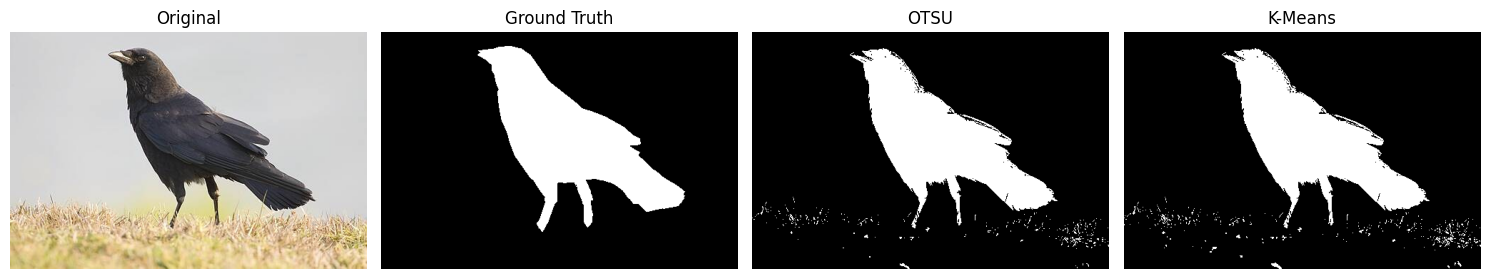

In [ ]:
# Assignment 1 Q2. 

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

img = cv2.imread("./data/American_Crow_0014_25287.jpg")
gt = cv2.imread("./data/American_Crow_0014_25287.png",0)
#_, gt = cv2.threshold(gt, 127, 255, cv2.THRESH_BINARY)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

_, otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

pixels = img.reshape((-1, 3))
pixels = np.float32(pixels)

kmeans = KMeans(n_clusters=2,random_state=0)

labels = kmeans.fit_predict(pixels)

centers = np.uint8(kmeans.cluster_centers_)
segmented = centers[labels.flatten()]
kseg = segmented.reshape(img.shape)

kgray = cv2.cvtColor(kseg,cv2.COLOR_RGB2GRAY)

_, kmeans_bin = cv2.threshold(kgray,127,255,cv2.THRESH_BINARY_INV)

def metrics(gt, pred):
    # MSE
    mse = mean_squared_error(gt.flatten(),pred.flatten())
    # IoU
    intersection = np.logical_and(gt > 0,pred > 0)
    union = np.logical_or(gt > 0,pred > 0)
    iou = np.sum(intersection) / np.sum(union)
    # Dice
    dice = (2 * np.sum(intersection)) / (np.sum(gt > 0) +np.sum(pred > 0))
    return mse, iou, dice

otsu_mse, otsu_iou, otsu_dice = metrics(gt, otsu)

k_mse, k_iou, k_dice = metrics(gt,kmeans_bin)

print("OTSU SEGMENTATION")
print("MSE  :", otsu_mse)
print("IoU  :", otsu_iou)
print("Dice :", otsu_dice)

print("\nK-MEANS SEGMENTATION")
print("MSE  :", k_mse)
print("IoU  :", k_iou)
print("Dice :", k_dice)

plt.figure(figsize=(15,15))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(otsu, cmap='gray')
plt.title("OTSU")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(kmeans_bin, cmap='gray')
plt.title("K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()

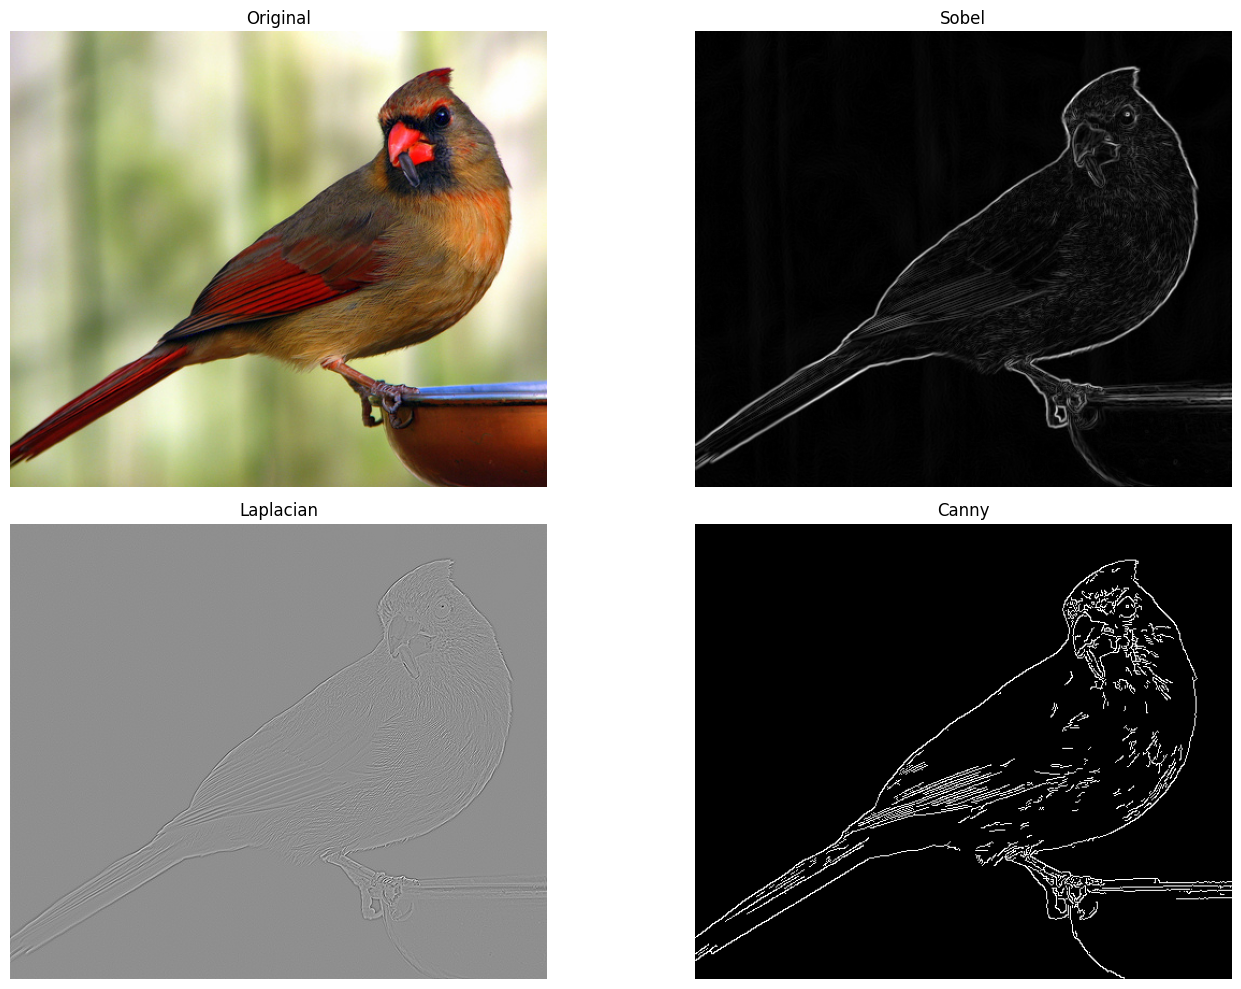

In [ ]:
# Edge Detection
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("./data/017.Cardinal/Cardinal_0103_17425.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Sobel
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)

# 2. Laplacian
laplacian = cv2.Laplacian(gray,cv2.CV_64F)

# 3. Canny
canny = cv2.Canny(gray,100,200)




# DISPLAY RESULTS
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

(-0.5, 499.5, 423.5, -0.5)

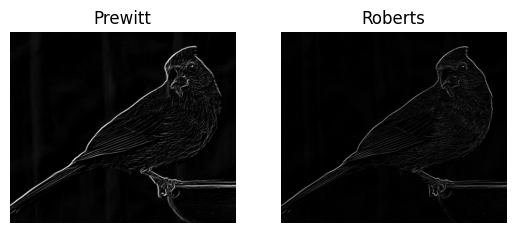

In [16]:
# ex
import numpy as np

# 4. Prewitt Edge Detector
kernelx = np.array([[1, 0, -1],
                    [1, 0, -1],
                    [1, 0, -1]])

kernely = np.array([[1, 1, 1],
                    [0, 0, 0],
                    [-1, -1, -1]])

prewittx = cv2.filter2D(gray, -1, kernelx)
prewitty = cv2.filter2D(gray, -1, kernely)
prewitt = cv2.magnitude(prewittx.astype(np.float64), prewitty.astype(np.float64))

# 5. Roberts Edge Detector
kernelx_roberts = np.array([[1, 0],
                            [0, -1]])

kernely_roberts = np.array([[0, 1],
                            [-1, 0]])

robertsx = cv2.filter2D(gray, -1, kernelx_roberts)
robertsy = cv2.filter2D(gray, -1, kernely_roberts)

roberts = cv2.magnitude(robertsx.astype(np.float64), robertsy.astype(np.float64))


# OUTPUT
plt.subplot(1,2,1)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(roberts, cmap='gray')
plt.title("Roberts")
plt.axis('off')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim


img = cv2.imread("./data/095.Baltimore_Oriole/Baltimore_Oriole_0014_87690.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# 1. Threshold Segmentation
# ==========================
_, thresh = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY
)

# ==========================
# 2. Otsu Segmentation
# ==========================
_, otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# ==========================
# 3. K-Means Segmentation
# ==========================
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (
    cv2.TERM_CRITERIA_EPS +
    cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)

k = 3

_, labels, centers = cv2.kmeans(
    pixel_values,
    k,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)

segmented = centers[labels.flatten()]
segmented = segmented.reshape(img_rgb.shape)

# ==========================
# 4. Watershed Segmentation
# ==========================
ret, thresh_ws = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(
    thresh_ws,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

ret, sure_fg = cv2.threshold(
    dist_transform,
    0.7 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

img_ws = img.copy()

markers = cv2.watershed(img_ws, markers)

img_ws[markers == -1] = [0, 0, 255]

# ==========================
# Distance Metrics
# ==========================
mse_value = mean_squared_error(
    gray.flatten(),
    thresh.flatten()
)

ssim_value = ssim(gray, thresh)

print("MSE :", mse_value)
print("SSIM:", ssim_value)

# ==========================
# Display Results
# ==========================
plt.figure(figsize=(14,10))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold Segmentation")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(otsu, cmap='gray')
plt.title("Otsu Segmentation")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(segmented)
plt.title("K-Means Segmentation")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(img_ws, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#!pip install tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds

# Load dataset information
dataset, info = tfds.load(
    'caltech_birds2011',
    split='train',
    with_info=True,
    as_supervised=True
)

print(info)

c:\Users\debaa\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...:   0%|          | 0/1 [02:26<?, ? url/s]